## Install and Import required libraries:

In [171]:
!pip install numpy pandas scikit-learn keras matplotlib seaborn openpyxl scikeras

^C


Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples, r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.svm import SVR
from scikeras.wrappers import KerasRegressor

from tensorflow import keras
from tensorflow.keras import layers, regularizers, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.regularizers import l2

In [ ]:
# Get dataset
data = pd.read_csv('housing.csv', header=0)

In [ ]:
# Print data shape
print(f"Data Shape: {data.shape}")

print(data.iloc[:, -1].value_counts())
data.head()

Data Shape: (20640, 10)
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [ ]:
# Check for missing values(NaN)
print("Missing values per column:\n", data.isnull().sum())

Missing values per column:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


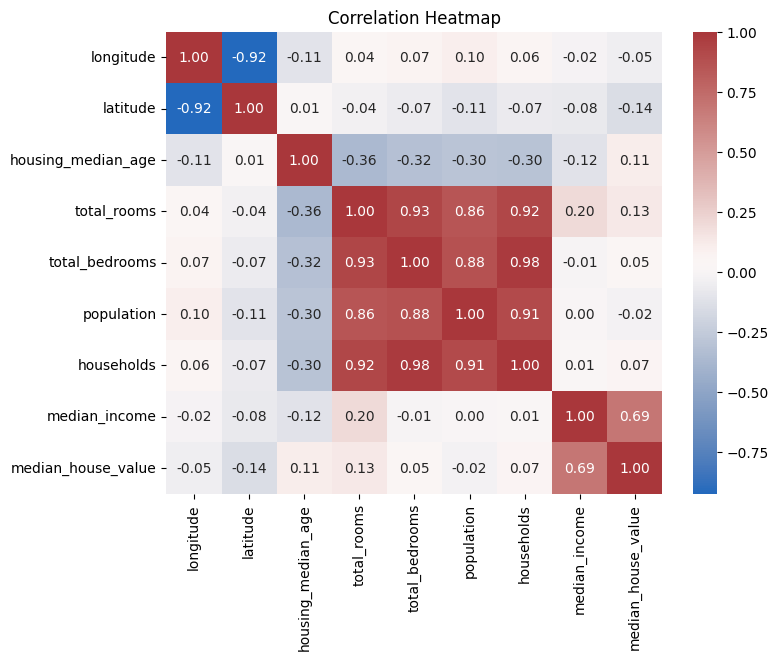

In [ ]:
# Correlation heatmap 
plt.figure(figsize=(8,6))
sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='vlag',
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

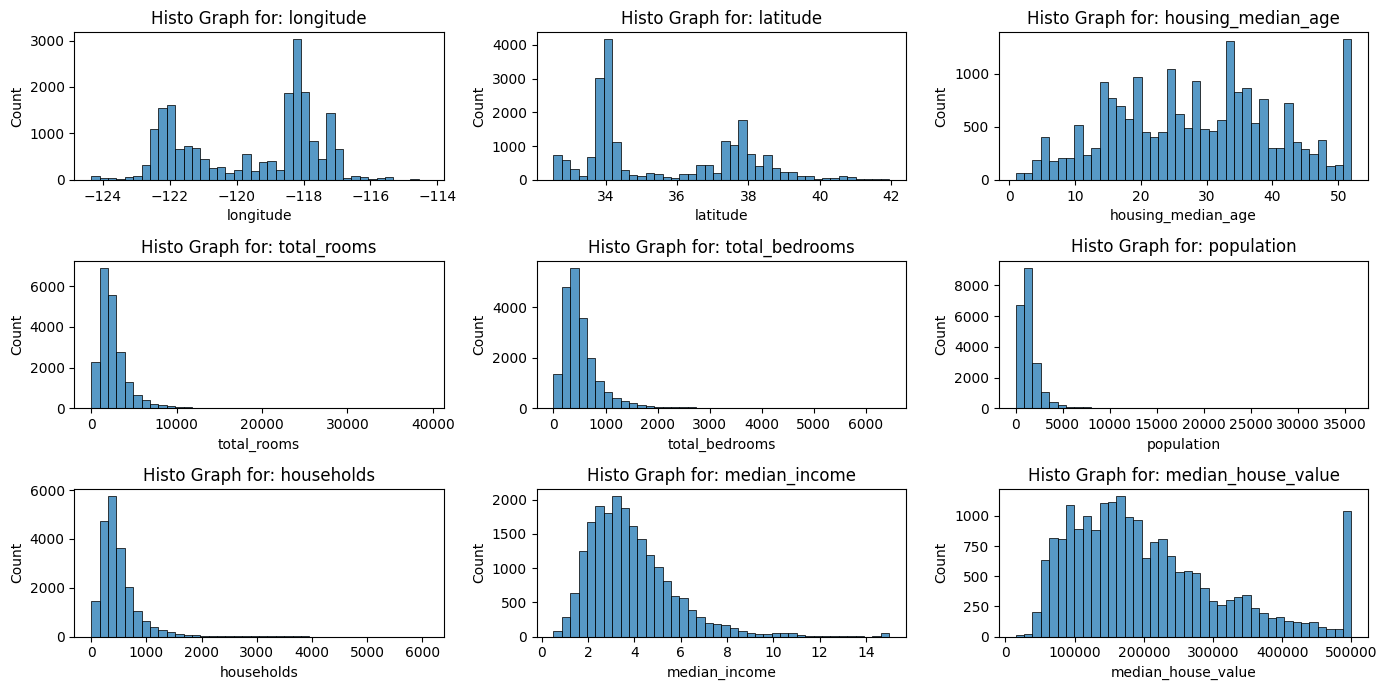

In [ ]:
# Histo graph for all numeric features
fig, axes = plt.subplots(3, 3, figsize=(14,7))

for i, col in enumerate(data.select_dtypes(include='number').columns):
    row = i//3
    col_idx = i%3
    ax = axes[row, col_idx]
    sns.histplot(data=data, x=col, ax=ax, bins=40)
    ax.set_title('Histo Graph for: ' + col)
plt.tight_layout()
plt.show()

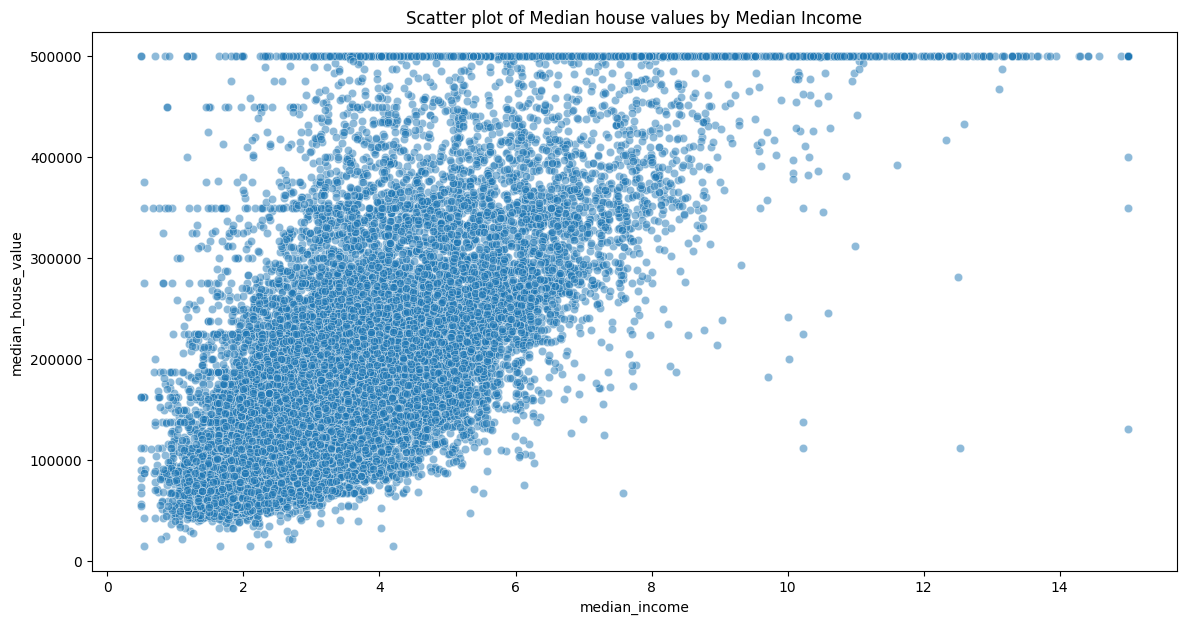

In [ ]:
# Scatter plot between median_house_value and Median_income
fig, ax = plt.subplots(figsize=(14,7))
sns.scatterplot(x= data['median_income'], y=data['median_house_value'], ax=ax, alpha=0.5)
ax.set_title('Scatter plot of Median house values by Median Income')
plt.show()

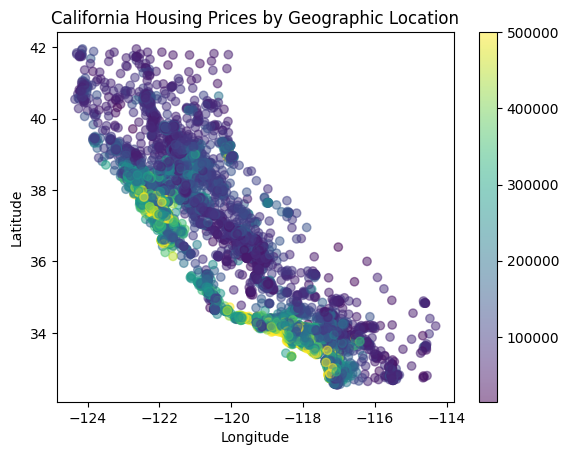

In [ ]:
# Geoplot for median_house_value using Lat/Lon
plt.scatter(x=data.longitude, y=data.latitude, c=data.median_house_value, cmap='viridis', alpha=0.5)
plt.title('California Housing Prices by Geographic Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar()
plt.show()

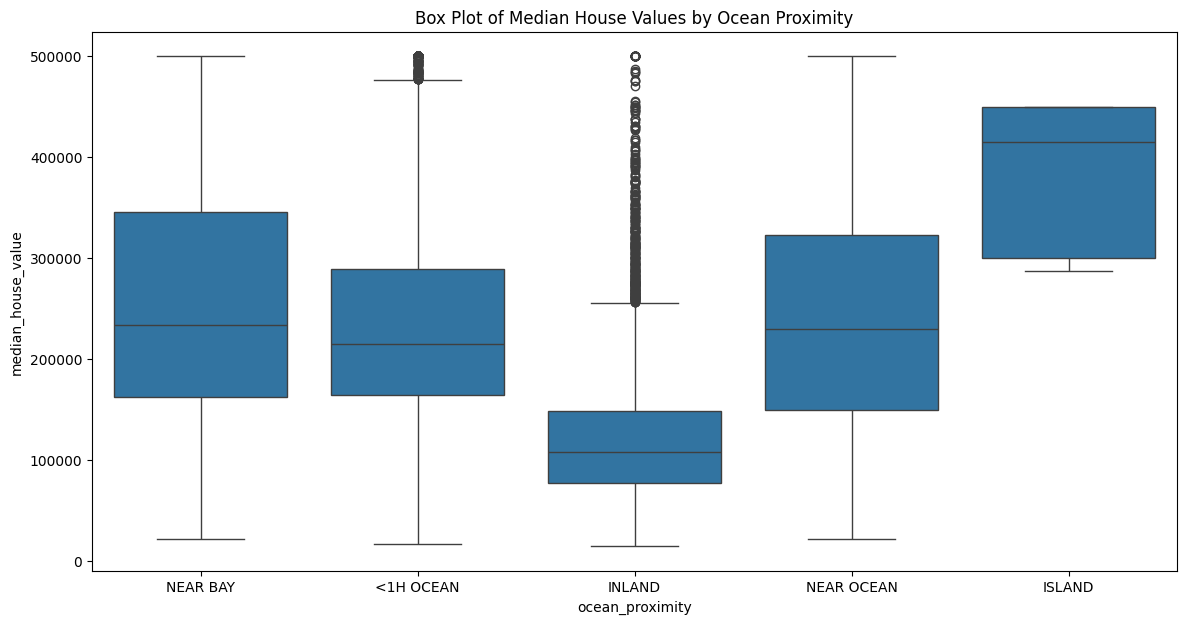

In [ ]:
# Box plot between median_house_value and ocean proximity
fig, ax = plt.subplots(figsize=(14,7))
sns.boxplot(x=data.ocean_proximity, y=data.median_house_value, ax=ax)
ax.set_title('Box Plot of Median House Values by Ocean Proximity')
plt.show()

In [ ]:
# One-hot encoding
encoded_data = pd.get_dummies(
    data,
    columns=['ocean_proximity'],
    drop_first=True
)

encoded_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,False,False,True,False
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,False,False,True,False
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,False,False,True,False
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,False,False,True,False
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,False,False,True,False


In [ ]:
# Separate features and target
X = encoded_data.drop('median_house_value', axis=1) # features
Y = encoded_data['median_house_value']              # target

# Spliting data into train and test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
# median of train set
train_median = X_train.median()

# setting NaN values to train median in both train and test
X_train = X_train.fillna(train_median)
X_test = X_test.fillna(train_median)

In [ ]:
# Checking missing values in train and test set 
print("Missing values per column in train set:\n", X_train.isnull().sum())
print("Missing values per column in test set:\n", X_test.isnull().sum())

Missing values per column in train set:
 longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64
Missing values per column in test set:
 longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64


In [ ]:
# Saving Longitude and Latitude values for ploting
Lon = X_train.longitude
Lat = X_train.latitude

In [ ]:
# Standardise features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# CLUSTERING

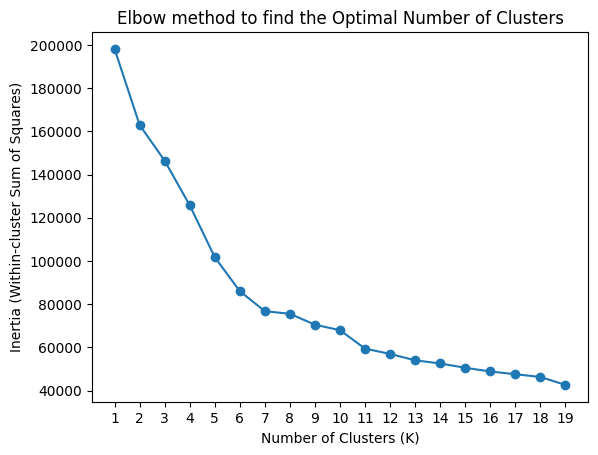

In [ ]:
# Kmeans with elbow method to find optimal cluster number
K = range(1,20)
inertia=[]

for k in K:
    kmeanModel = KMeans(n_clusters=k, init='k-means++',random_state=42).fit(X_train)
    inertia.append(kmeanModel.inertia_)

# Ploting for visual represntation to easily get elbow cluster 
plt.title('Elbow method to find the Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.xticks(K)
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.plot(K, inertia, marker='o')
plt.show()

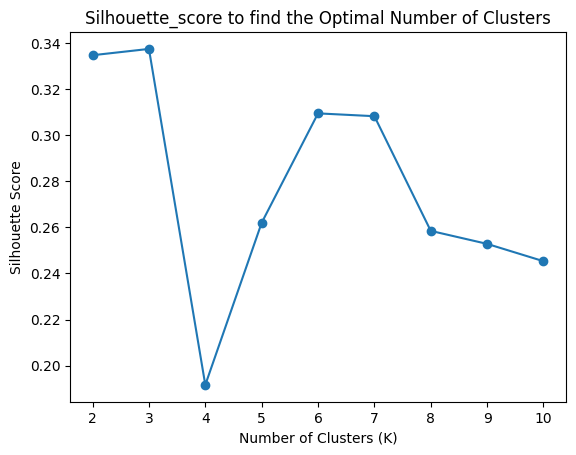

In [ ]:
# Silhouette score for optimal cluster number
sil_score = []
K = range(2,11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    sil_score.append(silhouette_score(X_train, kmeans.fit_predict(X_train)))

# Ploting for visual representation
plt.title('Silhouette_score to find the Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.xticks(K)
plt.ylabel('Silhouette Score')
plt.plot(K, sil_score, marker='o')
plt.show()

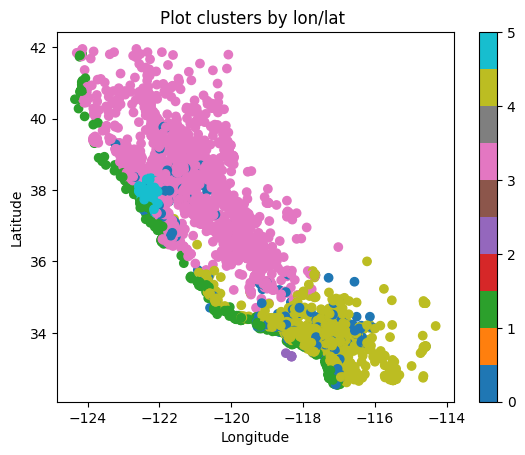

In [ ]:
# Initialize and Fit Kmean on training set
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(X_train)

#Adding new column for cluster lables
X_train_clustered = np.column_stack((X_train, kmeans.labels_)) 

# Ploting clusters 
plt.scatter(Lon, Lat, c=kmeans.labels_, cmap='tab10')
plt.title('Plot clusters by lon/lat ')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar()
plt.show()

In [ ]:
# Saving K-Means Cluster model
joblib.dump(kmeans, 'KMC_model.pkl')

['KMC_model.pkl']

In [ ]:
# KNN model with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, kmeans.labels_)

# Predicting on test set
prediction = knn.predict(X_test)

# Adding additinal column of predicted cluster
X_test_clustered = np.column_stack((X_test, prediction)) 

In [ ]:
# Saving K-Nearest Neighbors (KNN) model
joblib.dump(knn, 'KNN_model.pkl')

['KNN_model.pkl']

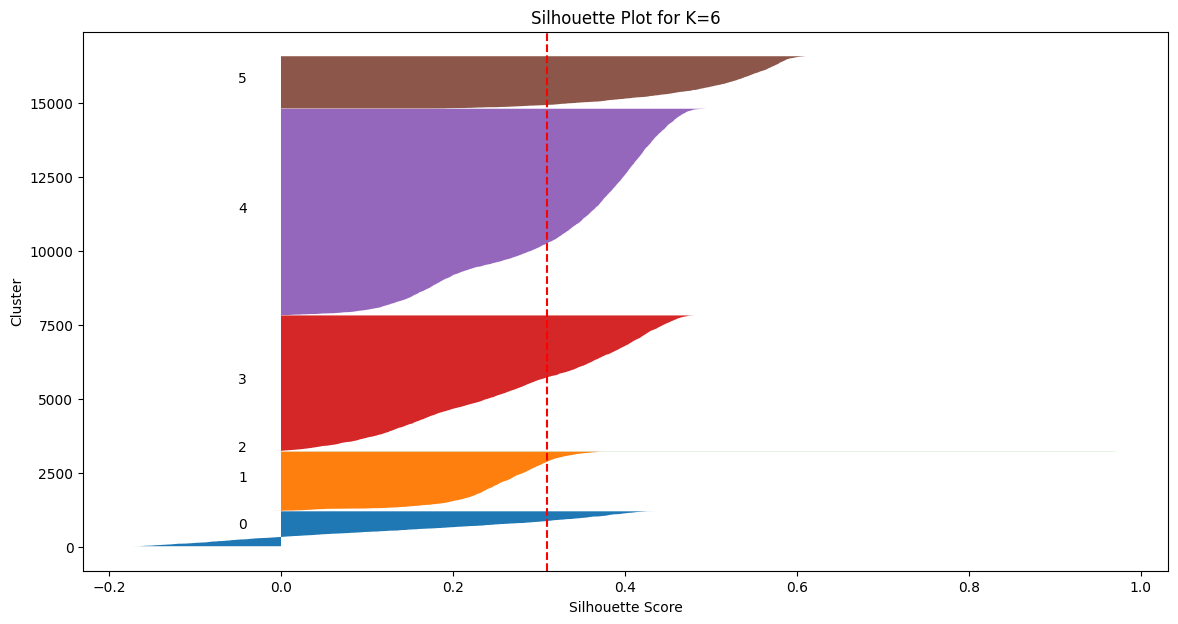

In [ ]:
# Silhouette plot on silhouette score grouped by clusters
sample_silhouette_values = silhouette_samples(X_train, kmeans.labels_)

fig, ax = plt.subplots(figsize=(14,7))
y_lower = 10
for i in range(6):
    ith_cluster_silhouette_values = sample_silhouette_values[kmeans.labels_ == i]

    ith_cluster_silhouette_values.sort()
    y_upper = y_lower + len(ith_cluster_silhouette_values)
    ax.fill_betweenx(y=np.arange(y_lower, y_upper), x1=ith_cluster_silhouette_values, x2=0)
    ax.text(-0.05, y_lower + len(ith_cluster_silhouette_values)/2, str(i))
    y_lower = y_upper + 10

# Ploting silhouette value in cluster grouping 
ax.axvline(x=sample_silhouette_values.mean(), color='red', linestyle='--')
ax.set_xlabel('Silhouette Score')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot for K=6')
plt.show()

# Regression Models

## Linear Regression

In [ ]:
# Linear Regression model
LR_model = LinearRegression()

# Params for tuning for best results
params_LR = {'fit_intercept': [True,False], 
             'positive': [True,False]}

grid_search = GridSearchCV(LR_model, params_LR, cv=5,scoring='neg_root_mean_squared_error')

grid_search.fit(X_train_clustered, Y_train)

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_}")

best_LR_model = grid_search.best_estimator_

Best Hyperparameters: {'fit_intercept': True, 'positive': False}
Best Score: -68443.00170241945


In [ ]:
# Saving prediction of LR model
prediction_train_LR = best_LR_model.predict(X_train_clustered)
prediction_test_LR = best_LR_model.predict(X_test_clustered)

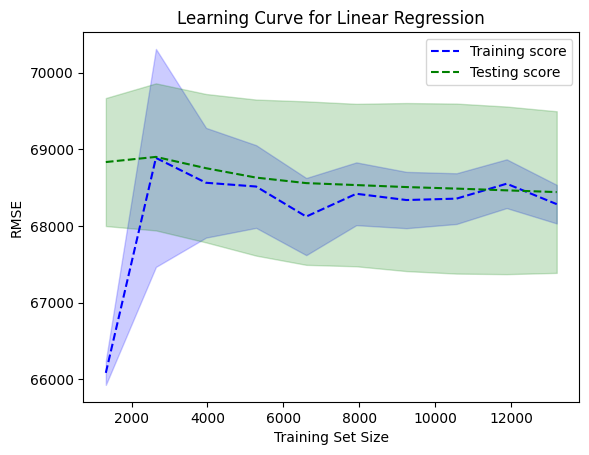

In [ ]:
# learnig curve for LR model
sizes_LR, training_scores, testing_scores = learning_curve(best_LR_model, X_train_clustered, Y_train,
                                                        cv=5, scoring='neg_root_mean_squared_error',
                                                        train_sizes=np.linspace(0.1, 1.0, 10))
                                                        
# Mean and Standard Deviation of training scores
mean_training_LR = np.mean(training_scores, axis=1)
Standard_Deviation_training_LR = np.std(training_scores, axis=1)

# Mean and Standard Deviation of testing scores
mean_testing_LR = np.mean(testing_scores, axis=1)
Standard_Deviation_testing_LR = np.std(testing_scores, axis=1)

# Dotted line for taining and test score
plt.plot(sizes_LR, -mean_training_LR, '--', color="b",  label="Training score")
plt.plot(sizes_LR, -mean_testing_LR, '--', color="g",  label="Testing score")

# Area in between standard deviation and score of traing and testing
plt.fill_between(sizes_LR, -mean_training_LR - Standard_Deviation_training_LR,
                -mean_training_LR + Standard_Deviation_training_LR, color='b', alpha=0.2)
plt.fill_between(sizes_LR, -mean_testing_LR - Standard_Deviation_testing_LR,
                -mean_testing_LR + Standard_Deviation_testing_LR, color='g', alpha=0.2)
plt.legend()
plt.title('Learning Curve for Linear Regression')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.show()

In [ ]:
# Saving Linear Regression model
joblib.dump(best_LR_model, 'LR_model.pkl')

['LR_model.pkl']

## Random Forest Regression

In [ ]:
# Random Forest Regression Model
RFR_model = RandomForestRegressor()

# Params for tuning 
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(RFR_model, param_grid, n_iter=20, cv=5,
                                    scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1)

random_search.fit(X_train_clustered, Y_train)

print(random_search.best_estimator_)

# Model with best params
best_RFR_model = random_search.best_estimator_

RandomForestRegressor(max_features='log2', n_estimators=200)


In [ ]:
# Prediction using best param model
prediction_train_RFR = best_RFR_model.predict(X_train_clustered)
prediction_test_RFR = best_RFR_model.predict(X_test_clustered)

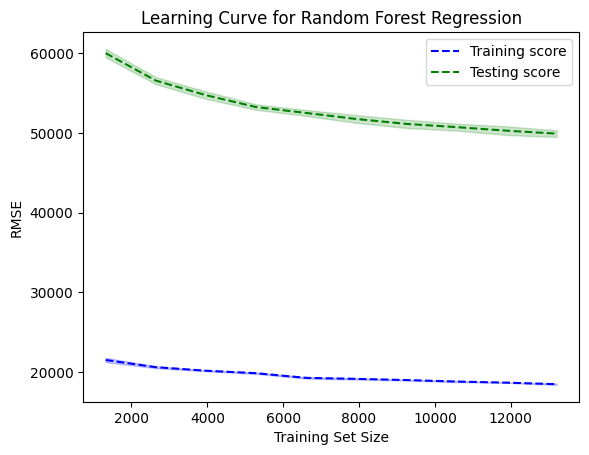

In [ ]:
# Learnig curve RFR Model
sizes_RFR, training_scores, testing_scores = learning_curve(best_RFR_model, X_train_clustered, Y_train,
                                                        cv=5, scoring='neg_root_mean_squared_error',
                                                        train_sizes=np.linspace(0.1, 1.0, 10))
                                                        
# Mean and Standard Deviation of training scores
mean_training_RFR = np.mean(training_scores, axis=1)
Standard_Deviation_training_RFR = np.std(training_scores, axis=1)

# Mean and Standard Deviation of testing scores
mean_testing_RFR = np.mean(testing_scores, axis=1)
Standard_Deviation_testing_RFR = np.std(testing_scores, axis=1)

# dotted line for training and test cross-validation score
plt.plot(sizes_RFR, -mean_training_RFR, '--', color="b",  label="Training score")
plt.plot(sizes_RFR, -mean_testing_RFR, '--', color="g",  label="Testing score")

plt.fill_between(sizes_RFR, -mean_training_RFR - Standard_Deviation_training_RFR,
                -mean_training_RFR + Standard_Deviation_training_RFR, color='b', alpha=0.2)
plt.fill_between(sizes_RFR, -mean_testing_RFR - Standard_Deviation_testing_RFR,
                -mean_testing_RFR + Standard_Deviation_testing_RFR, color='g', alpha=0.2)
plt.legend()
plt.title('Learning Curve for Random Forest Regression')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.show()

In [ ]:
# Saving Random forest regression model
joblib.dump(best_RFR_model, 'RFR_model.pkl')

['RFR_model.pkl']

## Support Vector Regression

In [ ]:
# Support Vector Regression model
SVR_model = SVR()

# Parameter Tuning for best results
param_grid =  {'C': [0.1, 1, 10, 100, 1000], 
			'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
			'kernel': ['rbf'],
            'epsilon': [0.1, 0.5, 1]} 

grid_search = RandomizedSearchCV(SVR_model, param_grid, cv=5,
                                    scoring='neg_root_mean_squared_error', n_jobs=-1, n_iter=20, random_state=42)

grid_search.fit(X_train_clustered, Y_train)

print(grid_search.best_estimator_)

# Model with best parameter
best_SVR_model = grid_search.best_estimator_

SVR(C=1000, epsilon=0.5, gamma=0.1)


In [ ]:
# Prediction using best param model
prediction_train_SVR = best_SVR_model.predict(X_train_clustered)
prediction_test_SVR = best_SVR_model.predict(X_test_clustered)

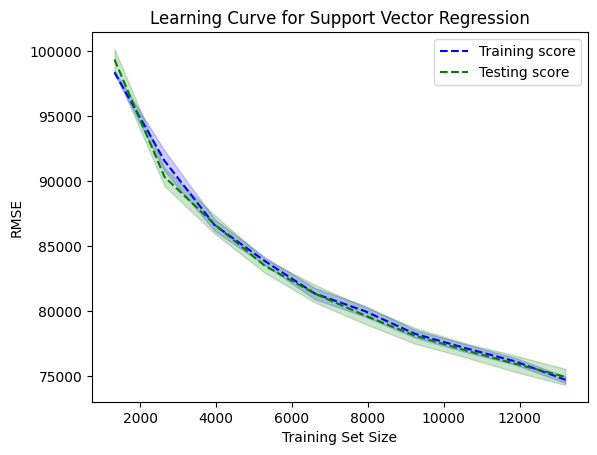

In [ ]:
# Learnig Curve for SVR model
sizes_SVR, training_scores, testing_scores = learning_curve(best_SVR_model, X_train_clustered, Y_train,
                                                        cv=5, scoring='neg_root_mean_squared_error',
                                                        train_sizes=np.linspace(0.1, 1.0, 10))
                                                        
# Mean and Standard Deviation of training scores
mean_training_SVR = np.mean(training_scores, axis=1)
Standard_Deviation_training_SVR = np.std(training_scores, axis=1)

# Mean and Standard Deviation of testing scores
mean_testing_SVR = np.mean(testing_scores, axis=1)
Standard_Deviation_testing_SVR = np.std(testing_scores, axis=1)

# dotted line for training and test cross-validation score
plt.plot(sizes_SVR, -mean_training_SVR, '--', color="b",  label="Training score")
plt.plot(sizes_SVR, -mean_testing_SVR, '--', color="g",  label="Testing score")
plt.fill_between(sizes_SVR, -mean_training_SVR - Standard_Deviation_training_SVR,
                -mean_training_SVR + Standard_Deviation_training_SVR, color='b', alpha=0.2)
plt.fill_between(sizes_SVR, -mean_testing_SVR - Standard_Deviation_testing_SVR,
                -mean_testing_SVR + Standard_Deviation_testing_SVR, color='g', alpha=0.2)
plt.legend()
plt.title('Learning Curve for Support Vector Regression')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.show()

In [ ]:
# Saving Support Vector Regression model
joblib.dump(best_SVR_model, 'SVR_model.pkl')

['SVR_model.pkl']

# Model Evaluation and Comparison

### Root Mean Squared Error (RMSE)

In [ ]:
# Linear Regression
RMSE_Train_LR = np.sqrt(mean_squared_error(Y_train, prediction_train_LR))
RMSE_Test_LR = np.sqrt(mean_squared_error(Y_test, prediction_test_LR))

# Random forest Regression
RMSE_Train_RFR = np.sqrt(mean_squared_error(Y_train, prediction_train_RFR))
RMSE_Test_RFR = np.sqrt(mean_squared_error(Y_test, prediction_test_RFR))

# Support Vector Regression
RMSE_Train_SVR = np.sqrt(mean_squared_error(Y_train, prediction_train_SVR))
RMSE_Test_SVR = np.sqrt(mean_squared_error(Y_test, prediction_test_SVR))

### R2

In [ ]:
# Linear Regression
R2_Train_LR = r2_score(Y_train, prediction_train_LR)
R2_Test_LR = r2_score(Y_test, prediction_test_LR)

# Random forest Regression
R2_Train_RFR = r2_score(Y_train, prediction_train_RFR)
R2_Test_RFR = r2_score(Y_test, prediction_test_RFR)

# Support Vector Regression
R2_Train_SVR = r2_score(Y_train, prediction_train_SVR)
R2_Test_SVR = r2_score(Y_test, prediction_test_SVR)

### MAE

In [ ]:
# Linear Regression
MAE_Train_LR = mean_absolute_error(Y_train, prediction_train_LR)
MAE_Test_LR = mean_absolute_error(Y_test, prediction_test_LR)

# Random forest Regression
MAE_Train_RFR = mean_absolute_error(Y_train, prediction_train_RFR)
MAE_Test_RFR = mean_absolute_error(Y_test, prediction_test_RFR)

# Support Vector Regression
MAE_Train_SVR = mean_absolute_error(Y_train, prediction_train_SVR)
MAE_Test_SVR = mean_absolute_error(Y_test, prediction_test_SVR)

In [ ]:
results = {
    'Model': ['Linear Regression', 'Random Forest Regressor', 'SVR'], 
    'Train R2': [R2_Train_LR, R2_Train_RFR, R2_Train_SVR],
    'Test R2': [R2_Test_LR, R2_Test_RFR, R2_Test_SVR],
    'Train MAE': [MAE_Train_LR, MAE_Train_RFR, MAE_Train_SVR],
    'Test MAE': [MAE_Test_LR, MAE_Test_RFR, MAE_Test_SVR],
    'Train RMSE': [RMSE_Train_LR, RMSE_Train_RFR, RMSE_Train_SVR],
    'Test RMSE': [RMSE_Test_LR, RMSE_Test_RFR, RMSE_Test_SVR]
}

results_df = pd.DataFrame(results).set_index('Model')
display(results_df)

,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE
Model,,,,,,
Linear Regression,0.645941,0.649698,49404.903578,50639.909056,68301.314799,69685.663222
Random Forest Regressor,0.974992,0.821006,12110.351450,33167.742493,18152.289209,49812.853573
SVR,0.600149,0.593580,49361.965211,50764.136112,72583.907422,75060.138377


### Model Prediction and Residual Comparison

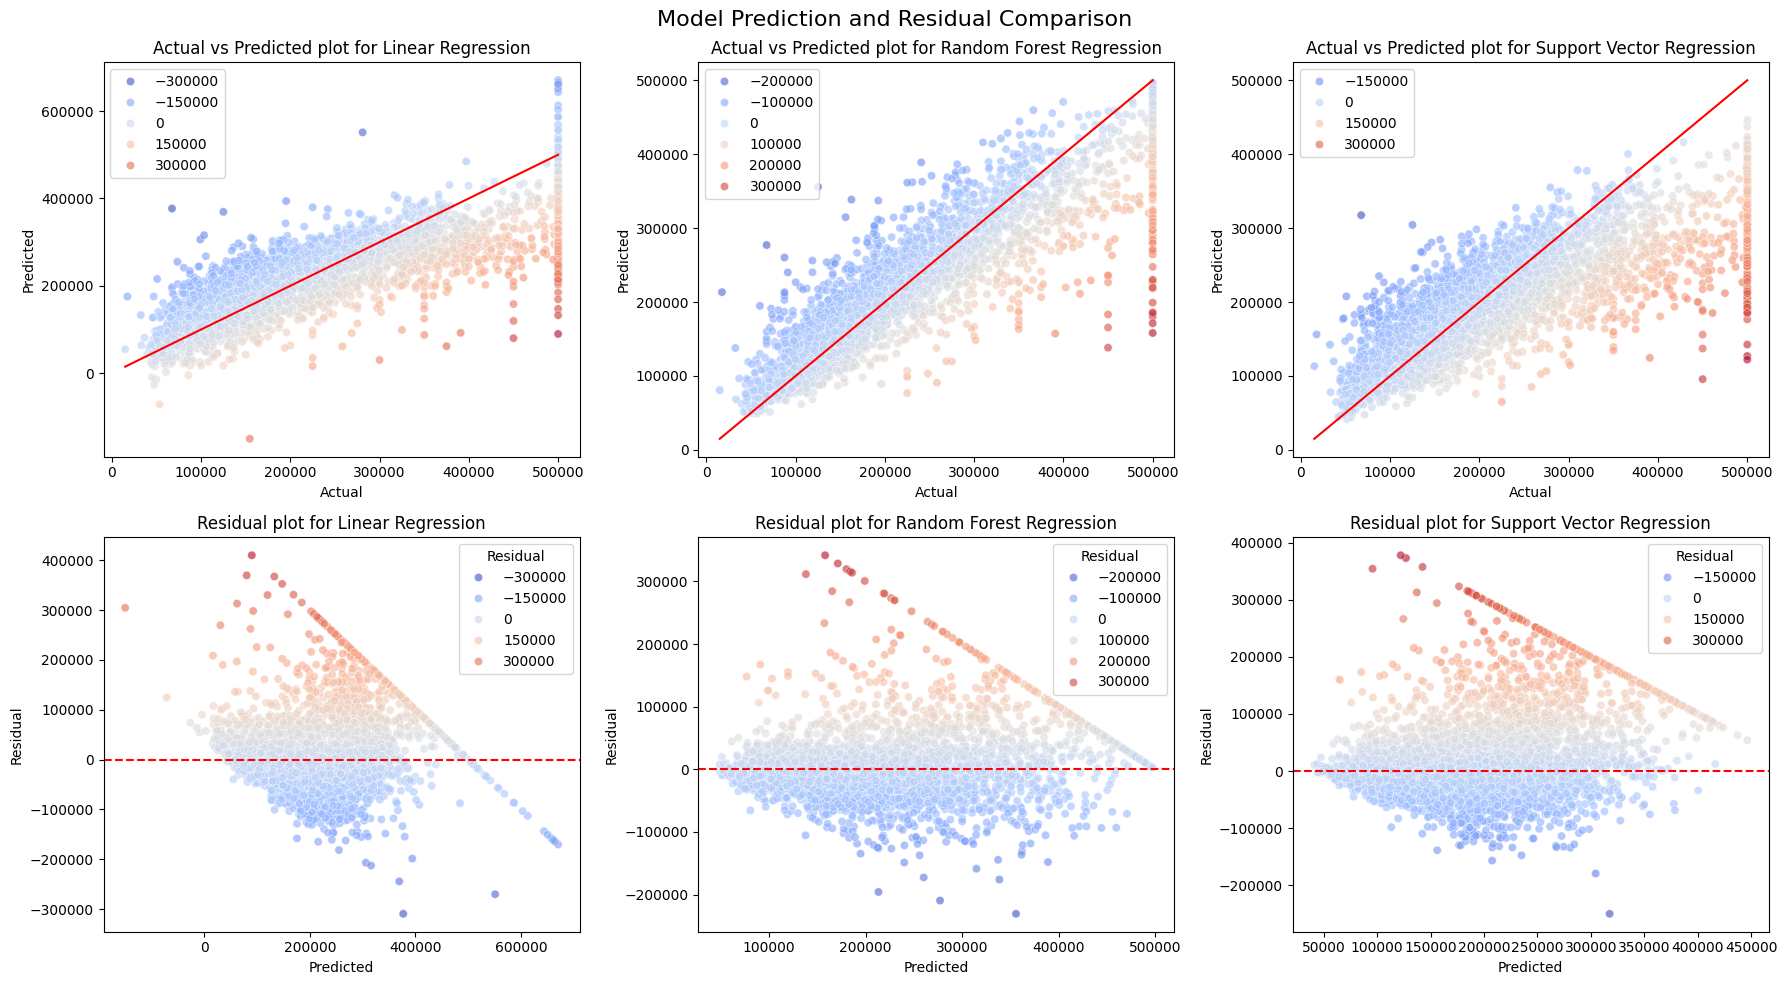

In [ ]:
# Acutal vs Prediction and Residual plot
fig, axes = plt.subplots(2, 3, figsize=(18,10))

models = [('Linear Regression', prediction_test_LR),
          ('Random Forest Regression', prediction_test_RFR),
           ('Support Vector Regression', prediction_test_SVR)]
for i, (name, preds) in enumerate(models):
    residuals = (Y_test - preds).rename('Residual')
    sns.scatterplot(x=Y_test, y=preds, hue=residuals, palette='coolwarm', alpha=0.6, ax=axes[0, i])
    sns.lineplot(x=[Y_test.min(), Y_test.max()], y=[Y_test.min(), Y_test.max()], color='red', ax=axes[0, i])
    axes[0, i].set_title(f"Actual vs Predicted plot for {name}")
    axes[0, i].set_xlabel('Actual')
    axes[0, i].set_ylabel('Predicted')

    sns.scatterplot(x=preds, y=residuals, hue=residuals, palette='coolwarm', alpha=0.6, ax=axes[1, i])
    axes[1, i].axhline(y=0, color='red', linestyle='--')
    axes[1, i].set_title(f"Residual plot for {name}")
    axes[1, i].set_xlabel('Predicted')
    axes[1, i].set_ylabel('Residual')

plt.suptitle('Model Prediction and Residual Comparison', fontsize=16)
plt.tight_layout()
plt.show()

### Learning Curve Comparison

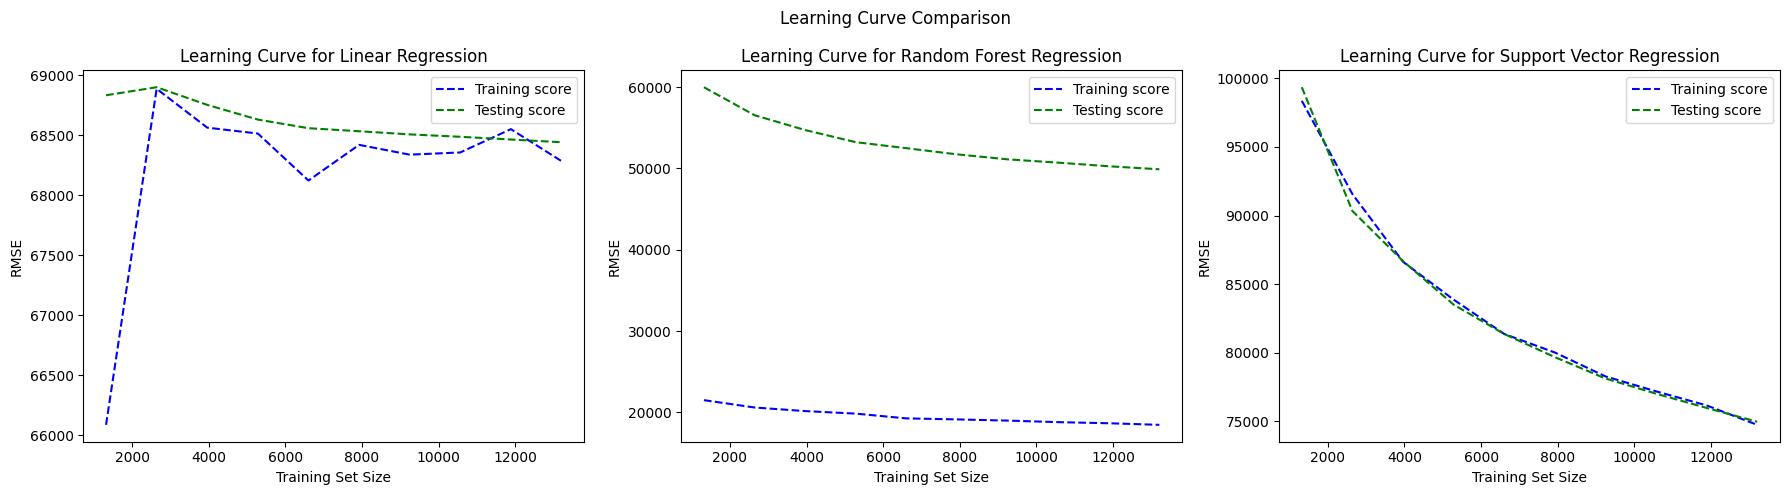

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ('Linear Regression', sizes_LR, mean_training_LR, mean_testing_LR),
    ('Random Forest Regression', sizes_RFR, mean_training_RFR, mean_testing_RFR),
    ('Support Vector Regression', sizes_SVR, mean_training_SVR, mean_testing_SVR)
]
for i, (name, sizes, mean_train, mean_test) in enumerate(models):
    axes[i].plot(sizes, -mean_train, '--', color="b",  label="Training score")
    axes[i].plot(sizes, -mean_test, '--', color="g",  label="Testing score")
    axes[i].set_title(f'Learning Curve for {name}')
    axes[i].set_xlabel('Training Set Size')
    axes[i].set_ylabel('RMSE')
    axes[i].legend()

plt.suptitle('Learning Curve Comparison')
plt.tight_layout()
plt.show()

### BAR chart for models

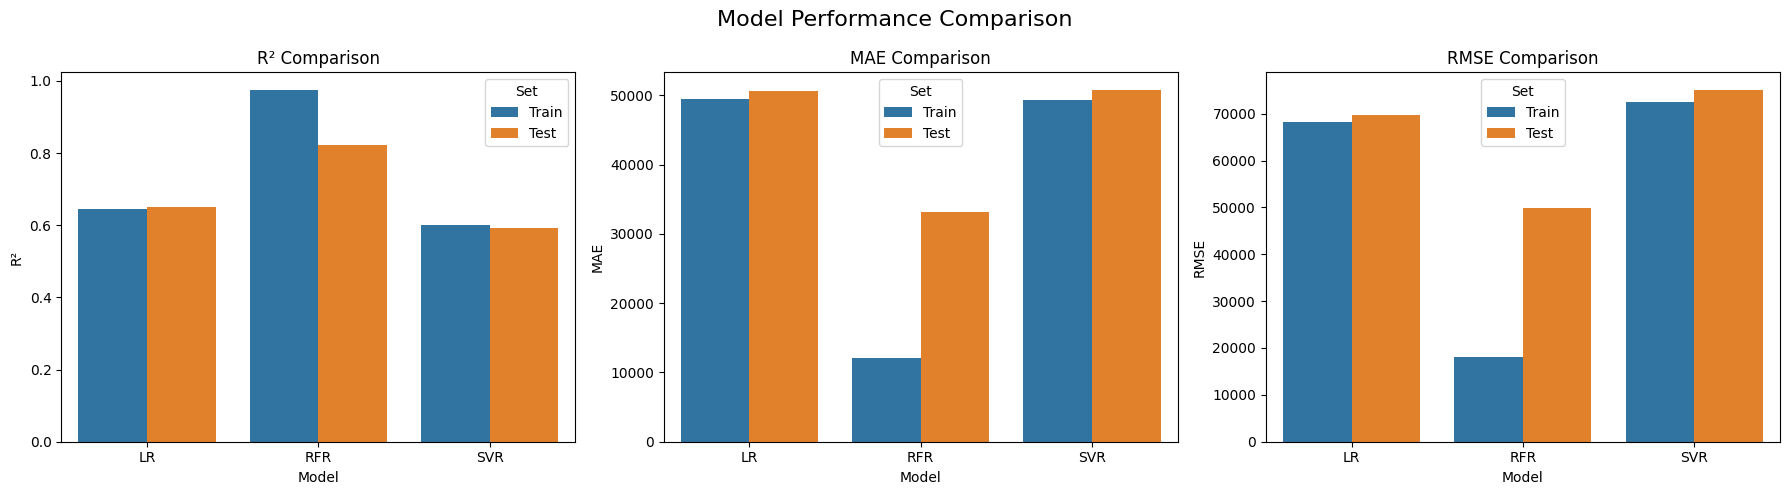

In [ ]:
# Model comparision Bar plot 
metrics_df = pd.DataFrame({
    'Model': ['LR', 'LR', 'RFR', 'RFR', 'SVR', 'SVR'],
    'Set': ['Train', 'Test', 'Train', 'Test', 'Train', 'Test'],
    'R2': [R2_Train_LR, R2_Test_LR, R2_Train_RFR, R2_Test_RFR, R2_Train_SVR, R2_Test_SVR],
    'MAE': [MAE_Train_LR, MAE_Test_LR, MAE_Train_RFR, MAE_Test_RFR, MAE_Train_SVR, MAE_Test_SVR],
    'RMSE': [RMSE_Train_LR, RMSE_Test_LR, RMSE_Train_RFR, RMSE_Test_RFR, RMSE_Train_SVR, RMSE_Test_SVR]
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² bar chart
sns.barplot(data=metrics_df, x='Model', y='R2', hue='Set', ax=axes[0])
axes[0].set_title('R²')
axes[0].set_ylabel('R²')

# MAE bar chart
sns.barplot(data=metrics_df, x='Model', y='MAE', hue='Set', ax=axes[1])
axes[1].set_title('MAE')
axes[1].set_ylabel('MAE')

# RMSE bar chart
sns.barplot(data=metrics_df, x='Model', y='RMSE', hue='Set', ax=axes[2])
axes[2].set_title('RMSE')
axes[2].set_ylabel('RMSE')

plt.suptitle('Model Performance Comparison', fontsize=16)
plt.tight_layout()
plt.show()

# MLP

In [219]:
def mlp_model(units1=512, units2=256, units3=128, units4=64, activation='relu', lr=0.001):
    model = Sequential()
    model.add(Dense(units1, activation=activation,
                input_shape=(X_train_clustered.shape[1],))
            )
    model.add(Dense(units2, activation=activation, kernel_regularizer=l2(1e-4)))
    model.add(Dense(units3, activation=activation, kernel_regularizer=l2(1e-4)))
    model.add(Dense(units4, activation=activation, kernel_regularizer=l2(1e-4)))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model

In [221]:
regressor = KerasRegressor(
    model=mlp_model,
    verbose=0,
    epochs=50
)

In [222]:
params_mlp = {
    "model__units1": [512, 768],
    "model__units2": [256, 512],
    "model__units3": [128, 256],
    "model__units4": [64, 128],
    "model__activation": ["relu", "elu"],
    "model__lr": [0.0005, 0.001, 0.005],
    "batch_size": [32, 64]
}

best_param_model = RandomizedSearchCV(estimator=regressor, param_distributions=params_mlp,
    n_iter=10, cv=3, scoring='r2',
    verbose=1, n_jobs=1, random_state=42
)

In [223]:
best_param_model.fit(X_train_clustered, Y_train)
best_params = best_param_model.best_params_
print(best_params)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\Bhavesh Bhargava\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Bhavesh Bhargava\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Bhavesh Bhargava\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local

{'model__units4': 128, 'model__units3': 128, 'model__units2': 512, 'model__units1': 768, 'model__lr': 0.005, 'model__activation': 'relu', 'batch_size': 32}


In [225]:
# Retrain final model with early stopping
final_mlp_model = mlp_model(
    units1=best_params['model__units1'],
    units2=best_params['model__units2'],
    units3=best_params['model__units3'],
    units4=best_params['model__units4'],
    activation=best_params['model__activation'],
    lr=best_params['model__lr']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = final_mlp_model.fit(X_train_clustered, Y_train,
                         validation_split=0.2,
                         epochs=200,
                         callbacks=[early_stop])

Epoch 1/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 7961071616.0000 - mae: 60713.8477 - val_loss: 4678476288.0000 - val_mae: 49022.9727
Epoch 2/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4586438144.0000 - mae: 47883.0664 - val_loss: 4382436352.0000 - val_mae: 46445.2812
Epoch 3/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4378877952.0000 - mae: 46802.3789 - val_loss: 4310303744.0000 - val_mae: 45422.6641
Epoch 4/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4196634112.0000 - mae: 45696.9141 - val_loss: 4243985408.0000 - val_mae: 46066.2773
Epoch 5/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3997022464.0000 - mae: 44579.2188 - val_loss: 3978401280.0000 - val_mae: 45975.3672
Epoch 6/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3795143936.0000 - mae: 43633.8711 - val_loss: 3899050752.0000 - val_mae: 43620.4023
Epoch 7/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3732502528.0000 - mae: 43030.4961 - val_loss: 3688965376.0000 - val_m

In [229]:
Y_train_pred = final_mlp_model.predict(X_train_clustered)
Y_test_pred = final_mlp_model.predict(X_test_clustered)


516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [231]:
print("\nBaseline Model Performance:")
print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_test_pred)))
print("MAE:", mean_absolute_error(Y_test, Y_test_pred))
print("R²:", r2_score(Y_test, Y_test_pred))
mape = mean_absolute_percentage_error(Y_test, Y_test_pred)
print("MAPE:", mape * 100, "%")


Baseline Model Performance:
RMSE: 52189.047126767895
MAE: 34698.02734375
R²: 0.8035215139389038
MAPE: 18.884791433811188 %


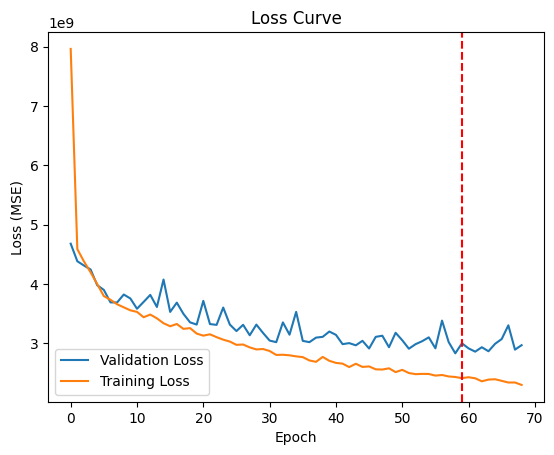

In [232]:
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['loss'], label='Training Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
best_epoch = len(history.history['loss']) - 10
plt.axvline(x=best_epoch, color='red', linestyle='--', label='Early Stop')
plt.title("Loss Curve")
plt.show()